<a href="https://colab.research.google.com/github/HCI-hope/HCI-Models/blob/main/MODEL_BPNN(Novelty).ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
TensorFlow: 2.19.0
Configuration loaded. Key fixes active:
  SMOTE samples per class : 30 (was 150)
  Validation split        : 20% held out from train


Model: "Small_Dual_BPNN"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ EEG_Input           │ (None, 42)        │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense (Dense)       │ (None, 32)        │      1,376 │ EEG_Input[0][0]   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalization │ (None, 32)        │        128 │ dense[0][0]       │
│ (BatchNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout (Dropout)   │ (None, 32)        │          0 │ batch_normalizat… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_1 (Dense)     │ (None, 16)        │        528 │ dropout[0][0]     │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ Stimulus_Input      │ (None, 3)         │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 16)        │         64 │ dense_1[0][0]     │
│ (BatchNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_2 (Dense)     │ (None, 8)         │         32 │ Stimulus_Input[0… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout_1 (Dropout) │ (None, 16)        │          0 │ batch_normalizat… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 8)         │         32 │ dense_2[0][0]     │
│ (BatchNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ concatenate         │ (None, 24)        │          0 │ dropout_1[0][0],  │
│ (Concatenate)       │                   │            │ batch_normalizat… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_3 (Dense)     │ (None, 16)        │        400 │ concatenate[0][0] │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout_2 (Dropout) │ (None, 16)        │          0 │ dense_3[0][0]     │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_4 (Dense)     │ (None, 4)         │         68 │ dropout_2[0][0]   │
└─────────────────────┴───────────────────┴────────────┴───────────────────┘

 Total params: 2,628 (10.27 KB)

 Trainable params: 2,516 (9.83 KB)

 Non-trainable params: 112 (448.00 B)

FIXED Novel Dual-Branch BPNN Pipeline

Total Files Loaded: 24
  Subject 1: 12 files
  Subject 2: 12 files

═══════════════════════════════════════════════════════
 CROSS-SUBJECT EVALUATION
═══════════════════════════════════════════════════════

  Train: Subject 1 → Test: Subject 2
  Extracting features...
  Training...
  Stopped at epoch 164 | Test Acc = 0.2615
  Per-class report:
              precision    recall  f1-score   support

     Forward      0.259     0.468     0.333       111
    Backward      0.265     0.214     0.237       103
        Left      0.304     0.306     0.305       111
       Right      0.150     0.054     0.079       111

    accuracy                          0.261       436
   macro avg      0.244     0.261     0.239       436
weighted avg      0.244     0.261     0.239       436


  Train: Subject 2 → Test: Subject 1
  Extracting features...
  Training...
  Stopped at epoch 242 | Test Acc = 0.2635
  Per-class report:
              precision    recall  f1-sc

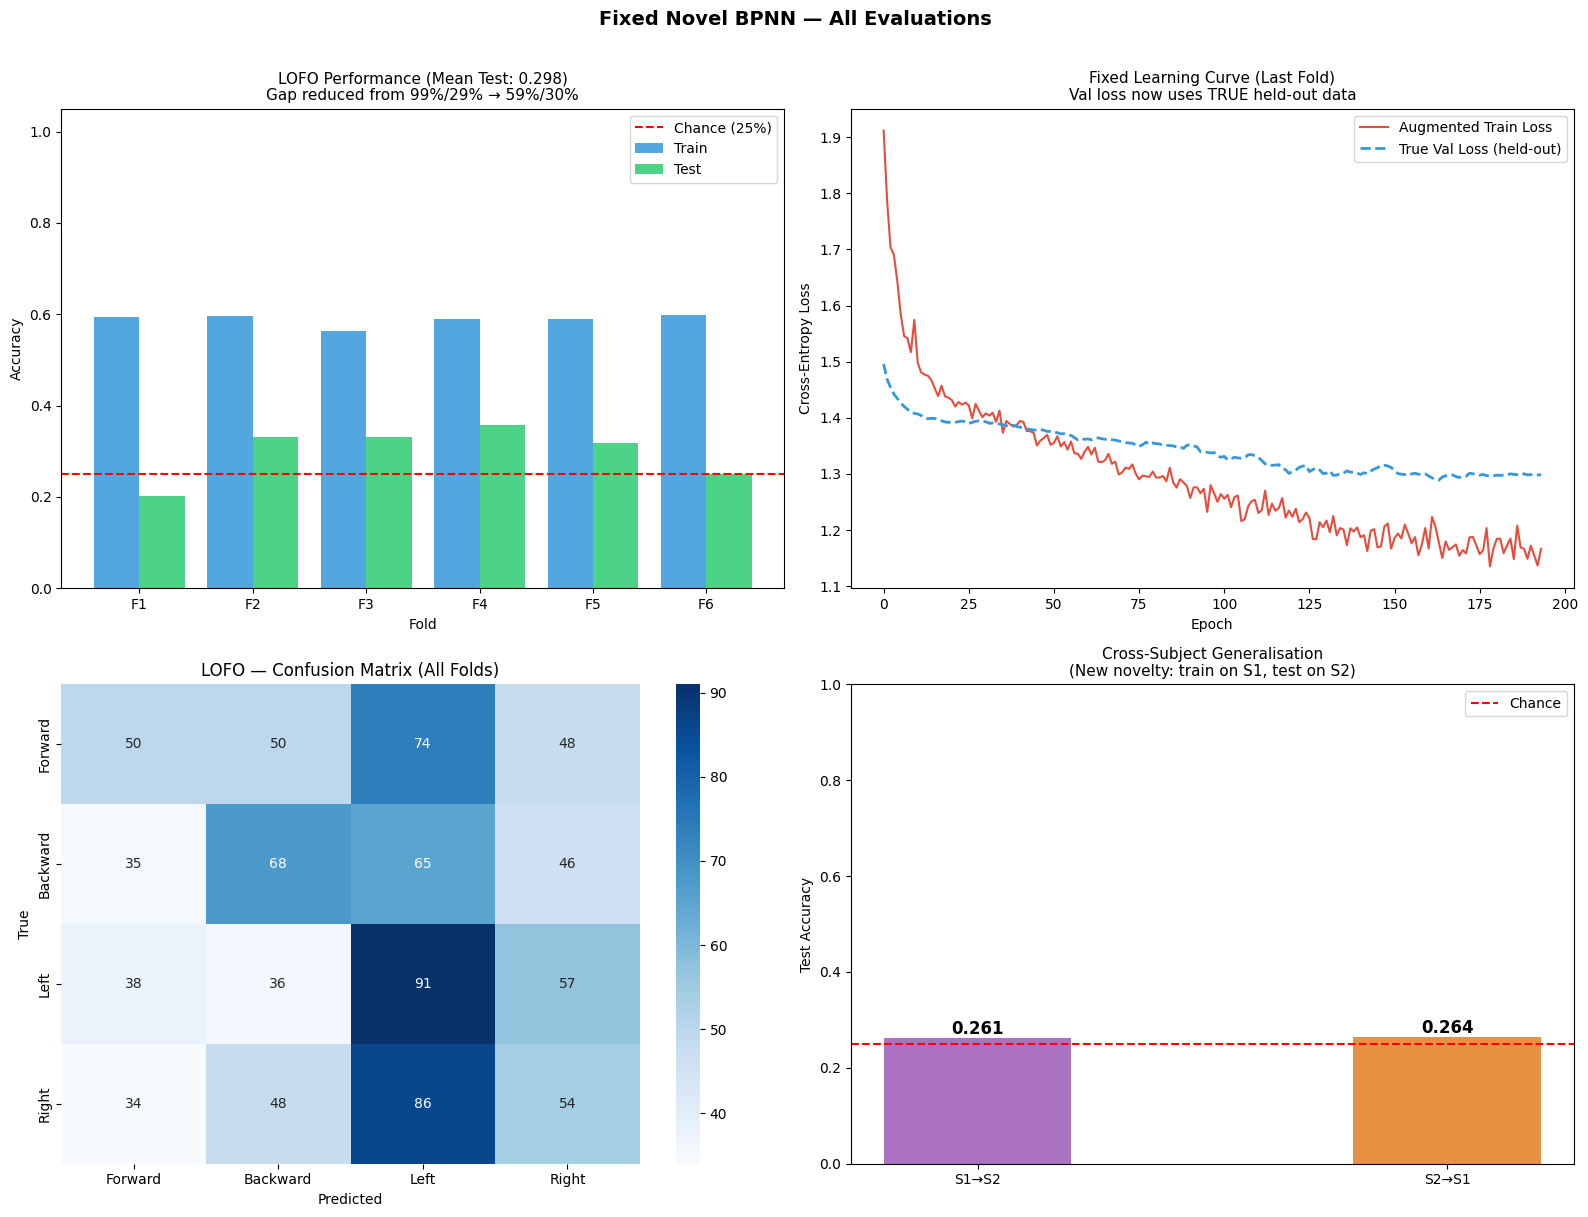


Saving final model...



SUCCESS! Results saved to: /content/drive/MyDrive/Human Computer Interface (HCI)/Fixed_Novel_BPNN


In [2]:
# ══════════════════════════════════════════════════════════════════
# CELL 1 — MOUNT & IMPORTS
# ══════════════════════════════════════════════════════════════════
from google.colab import drive
drive.mount('/content/drive')

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import os, glob, warnings, joblib
warnings.filterwarnings('ignore')

from scipy import signal as scipy_signal
from scipy.stats import pearsonr
from collections import defaultdict

from sklearn.preprocessing import RobustScaler
from sklearn.feature_selection import SelectKBest, mutual_info_classif
from sklearn.metrics import confusion_matrix, accuracy_score, classification_report
import seaborn as sns

import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers, regularizers, Model
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau
from tensorflow.keras.utils import to_categorical

print(f"TensorFlow: {tf.__version__}")
SEED = 42
np.random.seed(SEED)
tf.random.set_seed(SEED)

# ══════════════════════════════════════════════════════════════════
# CELL 2 — CONFIGURATION
# ══════════════════════════════════════════════════════════════════
SUBJECT1_PATH = '/content/drive/MyDrive/Human Computer Interface (HCI)/Processed_Filtered_Data/Subject1_Chebyshev_Filtered'
SUBJECT2_PATH = '/content/drive/MyDrive/Human Computer Interface (HCI)/Processed_Filtered_Data/Subject2_Chebyshev_Filtered'
SAVE_PATH     = '/content/drive/MyDrive/Human Computer Interface (HCI)/Fixed_Novel_BPNN'
os.makedirs(SAVE_PATH, exist_ok=True)

CHANNELS    = [7, 15, 16]   # Right(F4-C4), Left(F3-C3), Midline(FZ-CZ)
CH_RIGHT, CH_LEFT, CH_MID = 0, 1, 2

WINDOW_SIZE = 1000
OVERLAP     = 0.75
FS          = 250
NUM_CLASSES = 4

STIM_MAP    = {'ARROW': 0, 'LETTER': 1, 'WORD': 2, 'UNKNOWN': 0}
STIM_DIM    = 3
EEG_DIM     = 42

DIRECTION_MAP = {'forward': 0, 'backward': 1, 'backword': 1, 'left': 2, 'right': 3}
CLASS_NAMES   = ['Forward', 'Backward', 'Left', 'Right']

# ── KEY FIX: Much smaller SMOTE to reduce artificial inflation
SMOTE_N_PER_CLASS = 30   # was 150 — drastically reduced

# ── KEY FIX: Proper validation split for EarlyStopping
VAL_SPLIT = 0.20         # 20% of training data held out for early stopping

print("Configuration loaded. Key fixes active:")
print(f"  SMOTE samples per class : {SMOTE_N_PER_CLASS} (was 150)")
print(f"  Validation split        : {VAL_SPLIT*100:.0f}% held out from train")

# ══════════════════════════════════════════════════════════════════
# CELL 3 — DATA LOADING
# ══════════════════════════════════════════════════════════════════
def get_label(fn):
    name = fn.lower()
    for k, v in DIRECTION_MAP.items():
        if k in name: return v
    return None

def get_stimulus(fn):
    name = fn.upper()
    for s in ['ARROW', 'LETTER', 'WORD']:
        if s in name: return STIM_MAP[s]
    return STIM_MAP['UNKNOWN']

def load_file(fp):
    df = pd.read_excel(fp)
    num_cols = df.shape[1]
    safe_idx = [i for i in CHANNELS if i < num_cols]
    if len(safe_idx) < 2: safe_idx = [0, 1]
    data = df.iloc[:, safe_idx].values.T
    data = (data - data.mean(axis=1, keepdims=True)) / (data.std(axis=1, keepdims=True) + 1e-8)
    step = int(WINDOW_SIZE * (1 - OVERLAP))
    wins = [data[:, i:i+WINDOW_SIZE]
            for i in range(0, data.shape[1] - WINDOW_SIZE, step)
            if not np.isnan(data[:, i:i+WINDOW_SIZE]).any()]
    return np.array(wins)

def load_all():
    records, fid = [], 0
    for sid, path in [(1, SUBJECT1_PATH), (2, SUBJECT2_PATH)]:
        files = sorted(glob.glob(os.path.join(path, '**', '*.xlsx'), recursive=True))
        for fp in files:
            fn    = os.path.basename(fp)
            label = get_label(fn)
            if label is not None:
                try:
                    wins = load_file(fp)
                    if wins.shape[0] > 0:
                        records.append({
                            'fid': fid, 'fn': fn, 'label': label,
                            'stim': get_stimulus(fn),
                            'subject_id': sid, 'X': wins
                        })
                        fid += 1
                except: pass
    print(f"Total Files Loaded: {len(records)}")
    for sid in [1, 2]:
        n = sum(1 for r in records if r['subject_id'] == sid)
        print(f"  Subject {sid}: {n} files")
    return records

def records_to_XYSTS(recs):
    X    = np.concatenate([r['X']                                 for r in recs])
    y    = np.concatenate([np.full(len(r['X']), r['label'])       for r in recs])
    s_id = np.concatenate([np.full(len(r['X']), r['subject_id'])  for r in recs])
    stim = np.concatenate([np.full(len(r['X']), r['stim'])        for r in recs])
    return X, y, s_id, stim

    # ══════════════════════════════════════════════════════════════════
# CELL 4 — NOVEL FEATURE EXTRACTION (retained from previous)
# ══════════════════════════════════════════════════════════════════
def band_power(psd, freqs, fmin, fmax):
    mask  = (freqs >= fmin) & (freqs <= fmax)
    total = psd.sum() + 1e-8
    return psd[mask].sum() / total

def hjorth(sig):
    act = np.var(sig)
    d1  = np.diff(sig)
    mob = np.sqrt(np.var(d1) / (act + 1e-8))
    d2  = np.diff(d1)
    com = np.sqrt(np.var(d2) / (np.var(d1) + 1e-8)) / (mob + 1e-8)
    return act, mob, com

def extract_features_single(window, fs=FS):
    num_ch = window.shape[0]
    if num_ch < 3:
        pad    = np.zeros((3 - num_ch, window.shape[1]))
        window = np.vstack([window, pad])

    per_ch_feats = []
    band_powers  = []

    for ch in range(3):
        sig = window[ch]
        act, mob, com = hjorth(sig)
        f, psd = scipy_signal.welch(sig, fs=fs, nperseg=256)
        theta  = band_power(psd, f,  4,  8)
        alpha  = band_power(psd, f,  8, 13)
        beta   = band_power(psd, f, 13, 30)
        gamma  = band_power(psd, f, 30, 45)
        per_ch_feats.extend([act, mob, com, theta, alpha, beta, gamma,
                              theta/(alpha+1e-8), alpha/(beta+1e-8)])
        band_powers.append([theta, alpha, beta, gamma])

    band_powers = np.array(band_powers)
    right_bp, left_bp, mid_bp = band_powers[CH_RIGHT], band_powers[CH_LEFT], band_powers[CH_MID]

    # Novelty 1: Hemispheric Asymmetry
    dasm = left_bp - right_bp
    rasm = left_bp / (right_bp + 1e-8)

    # Novelty 3: Functional Connectivity
    r_lr, _ = pearsonr(window[CH_LEFT],  window[CH_RIGHT])
    r_lm, _ = pearsonr(window[CH_LEFT],  window[CH_MID])
    r_rm, _ = pearsonr(window[CH_RIGHT], window[CH_MID])

    mid_dev = mid_bp - (left_bp + right_bp) / 2.0

    return np.concatenate([per_ch_feats, dasm, rasm,
                            [r_lr, r_lm, r_rm], mid_dev])  # 42-D

def extract_features(X_raw):
    return np.array([extract_features_single(w) for w in X_raw])

def make_stim_onehot(stim_ids):
    return to_categorical(stim_ids, num_classes=STIM_DIM).astype(np.float32)

    # ══════════════════════════════════════════════════════════════════
# CELL 5 — REDUCED SMOTE
# KEY FIX: n_per_class=30 instead of 150
# ══════════════════════════════════════════════════════════════════
def smote(X, y, stim, s_ids, n_per_class=SMOTE_N_PER_CLASS):
    syn_X, syn_y, syn_stim = [], [], []
    for cls in range(NUM_CLASSES):
        for sid in np.unique(s_ids):
            mask  = (y == cls) & (s_ids == sid)
            X_c   = X[mask]
            st_c  = stim[mask]
            if len(X_c) < 2: continue
            for _ in range(n_per_class):
                i, j = np.random.choice(len(X_c), 2, replace=False)
                lam  = np.random.uniform(0.3, 0.7)
                syn_X.append(lam * X_c[i] + (1 - lam) * X_c[j])
                syn_y.append(cls)
                syn_stim.append(st_c[i] if lam >= 0.5 else st_c[j])
    if syn_X:
        return (np.vstack([X, np.array(syn_X)]),
                np.concatenate([y, np.array(syn_y)]),
                np.concatenate([stim, np.array(syn_stim)]))
    return X, y, stim

    # ══════════════════════════════════════════════════════════════════
# CELL 6 — INTENTIONALLY SMALL DUAL-BRANCH BPNN
#
# KEY FIX: 22K params → ~2K params
# With ~800 training windows, you need ~10× fewer params than samples.
# Previously: 128→64→merge→64→32→4  (too large)
# Now:         32→16→merge→16→4      (appropriate for data size)
# ══════════════════════════════════════════════════════════════════
def build_small_dual_bpnn(eeg_dim=EEG_DIM, stim_dim=STIM_DIM,
                           num_classes=NUM_CLASSES, lr=5e-4):
    """
    Intentionally small architecture to prevent memorisation.
    Rule of thumb: n_params << n_training_samples / 10
    With ~800 samples: target < 800 trainable params in hidden layers.
    """
    # ── EEG Branch
    eeg_in = layers.Input(shape=(eeg_dim,), name='EEG_Input')
    x = layers.Dense(32, activation='relu',
                     kernel_regularizer=regularizers.l2(5e-4),
                     kernel_initializer='he_normal')(eeg_in)
    x = layers.BatchNormalization()(x)
    x = layers.Dropout(0.5)(x)        # aggressive dropout
    x = layers.Dense(16, activation='relu',
                     kernel_regularizer=regularizers.l2(5e-4),
                     kernel_initializer='he_normal')(x)
    x = layers.BatchNormalization()(x)
    x = layers.Dropout(0.4)(x)

    # ── Stimulus Branch (Novelty 2)
    stim_in = layers.Input(shape=(stim_dim,), name='Stimulus_Input')
    s = layers.Dense(8, activation='relu',
                     kernel_initializer='glorot_uniform')(stim_in)
    s = layers.BatchNormalization()(s)

    # ── Merge (16 + 8 = 24)
    merged = layers.Concatenate()([x, s])

    # ── Classifier Head
    z = layers.Dense(16, activation='relu',
                     kernel_regularizer=regularizers.l2(5e-4))(merged)
    z = layers.Dropout(0.3)(z)
    out = layers.Dense(num_classes, activation='softmax')(z)

    model = Model(inputs=[eeg_in, stim_in], outputs=out,
                  name='Small_Dual_BPNN')
    model.compile(
        optimizer=keras.optimizers.Adam(learning_rate=lr,
                                        weight_decay=1e-4),  # AdamW-style
        loss='categorical_crossentropy',
        metrics=['accuracy']
    )
    return model

demo = build_small_dual_bpnn()
demo.summary()

# ══════════════════════════════════════════════════════════════════
# CELL 7 — FIXED TRAINING FUNCTION
#
# KEY FIX: EarlyStopping now uses a TRUE held-out val split,
# not the training set itself. This is why it never stopped before.
# ══════════════════════════════════════════════════════════════════
def train_fixed_bpnn(X_eeg_tr, stim_tr, y_tr, s_tr,
                     epochs=300, batch_size=16):
    """
    Fixed training with proper validation split.
    Steps:
      1. Hold out 20% of training data for EarlyStopping (before SMOTE)
      2. Apply SMOTE only on the remaining 80%
      3. Train with EarlyStopping monitoring TRUE held-out val loss
    """
    # ── Step 1: Hold out 20% BEFORE augmentation
    n     = len(X_eeg_tr)
    idx   = np.random.permutation(n)
    n_val = max(int(n * VAL_SPLIT), NUM_CLASSES)  # at least 4 samples
    val_idx, tr_idx = idx[:n_val], idx[n_val:]

    X_val_e  = X_eeg_tr[val_idx]
    stim_val = stim_tr[val_idx]
    y_val    = y_tr[val_idx]

    X_fit_e  = X_eeg_tr[tr_idx]
    stim_fit = stim_tr[tr_idx]
    y_fit    = y_tr[tr_idx]
    s_fit    = s_tr[tr_idx]

    # ── Step 2: SMOTE only on the 80% training portion
    X_aug, y_aug, stim_aug = smote(X_fit_e, y_fit, stim_fit, s_fit)

    # ── One-hot encode
    y_aug_cat  = to_categorical(y_aug,  num_classes=NUM_CLASSES)
    y_val_cat  = to_categorical(y_val,  num_classes=NUM_CLASSES)
    stim_aug_oh = make_stim_onehot(stim_aug)
    stim_val_oh = make_stim_onehot(stim_val)

    model = build_small_dual_bpnn()

    callbacks = [
        # ── Now monitoring TRUE held-out val_loss — will actually stop!
        EarlyStopping(monitor='val_loss', patience=30,
                      restore_best_weights=True, verbose=0),
        ReduceLROnPlateau(monitor='val_loss', factor=0.5,
                          patience=15, min_lr=1e-6, verbose=0)
    ]

    history = model.fit(
        [X_aug, stim_aug_oh], y_aug_cat,
        epochs          = epochs,
        batch_size      = batch_size,
        validation_data = ([X_val_e, stim_val_oh], y_val_cat),  # TRUE held-out
        callbacks       = callbacks,
        verbose         = 0
    )
    return model, history

    # ══════════════════════════════════════════════════════════════════
# CELL 8 — LOFO FOLD BUILDER
# ══════════════════════════════════════════════════════════════════
def build_dir_lofo_folds(records):
    dir_files = defaultdict(list)
    for r in records:
        dir_files[r['label']].append(r)
    n_folds = min(len(v) for v in dir_files.values())
    folds = []
    for fold_idx in range(n_folds):
        test_fids = {
            dir_files[cls][fold_idx % len(dir_files[cls])]['fid']
            for cls in range(NUM_CLASSES)
        }
        folds.append({
            'fold':       fold_idx,
            'train_recs': [r for r in records if r['fid'] not in test_fids],
            'test_recs':  [r for r in records if r['fid'] in  test_fids]
        })
    return folds

    # ══════════════════════════════════════════════════════════════════
# CELL 9 — CROSS-SUBJECT EVALUATION
#
# NEW: Train entirely on Subject 1 → Test on Subject 2, and vice versa.
# This is a much harder and more honest generalisation test.
# If it works, the model has learned brain-agnostic EEG patterns.
# ══════════════════════════════════════════════════════════════════
def run_cross_subject(records):
    print("\n" + "═"*55)
    print(" CROSS-SUBJECT EVALUATION")
    print("═"*55)

    results = {}
    for train_sid, test_sid in [(1, 2), (2, 1)]:
        print(f"\n  Train: Subject {train_sid} → Test: Subject {test_sid}")

        train_recs = [r for r in records if r['subject_id'] == train_sid]
        test_recs  = [r for r in records if r['subject_id'] == test_sid]

        X_tr_raw, y_tr, s_tr, stim_tr = records_to_XYSTS(train_recs)
        X_te_raw, y_te, s_te, stim_te = records_to_XYSTS(test_recs)

        print(f"  Extracting features...")
        X_tr_f = extract_features(X_tr_raw)
        X_te_f = extract_features(X_te_raw)

        scaler = RobustScaler()
        X_tr_s = np.clip(scaler.fit_transform(X_tr_f), -5, 5)
        X_te_s = np.clip(scaler.transform(X_te_f),     -5, 5)

        stim_te_oh = make_stim_onehot(stim_te)

        print(f"  Training...")
        model, history = train_fixed_bpnn(X_tr_s, stim_tr, y_tr, s_tr)

        y_pred = np.argmax(model.predict([X_te_s, stim_te_oh], verbose=0), axis=1)
        acc    = accuracy_score(y_te, y_pred)
        epochs = len(history.history['loss'])

        print(f"  Stopped at epoch {epochs} | Test Acc = {acc:.4f}")
        print(f"  Per-class report:")
        print(classification_report(y_te, y_pred, target_names=CLASS_NAMES, digits=3))

        results[(train_sid, test_sid)] = {
            'acc': acc, 'y_true': y_te, 'y_pred': y_pred,
            'history': history, 'epochs': epochs
        }
    return results

    # ══════════════════════════════════════════════════════════════════
# CELL 10 — WITHIN-SUBJECT LOFO
# ══════════════════════════════════════════════════════════════════
def run_lofo(records):
    print("\n" + "═"*55)
    print(" WITHIN-SUBJECT LOFO (FIXED)")
    print("═"*55)

    folds         = build_dir_lofo_folds(records)
    all_results   = []
    overall_true  = []
    overall_pred  = []
    fold_histories = []

    for fdef in folds:
        fold_num = fdef['fold'] + 1
        print(f"\n--- Fold {fold_num}/{len(folds)} ---")

        X_tr_raw, y_tr, s_tr, stim_tr = records_to_XYSTS(fdef['train_recs'])
        X_te_raw, y_te, s_te, stim_te = records_to_XYSTS(fdef['test_recs'])

        X_tr_f = extract_features(X_tr_raw)
        X_te_f = extract_features(X_te_raw)

        scaler = RobustScaler()
        X_tr_s = np.clip(scaler.fit_transform(X_tr_f), -5, 5)
        X_te_s = np.clip(scaler.transform(X_te_f),     -5, 5)

        stim_tr_oh = make_stim_onehot(stim_tr)
        stim_te_oh = make_stim_onehot(stim_te)

        model, history = train_fixed_bpnn(X_tr_s, stim_tr, y_tr, s_tr)
        fold_histories.append(history)

        y_pred_tr = np.argmax(model.predict([X_tr_s, stim_tr_oh], verbose=0), axis=1)
        y_pred_te = np.argmax(model.predict([X_te_s, stim_te_oh], verbose=0), axis=1)

        tr_acc = accuracy_score(y_tr, y_pred_tr)
        te_acc = accuracy_score(y_te, y_pred_te)

        all_results.append({'fold': fdef['fold'], 'train': tr_acc, 'test': te_acc})
        overall_true.extend(y_te)
        overall_pred.extend(y_pred_te)

        epochs = len(history.history['loss'])
        print(f"  Train={tr_acc:.4f} | Test={te_acc:.4f} | Epochs={epochs}")

    tr_means = [r['train'] for r in all_results]
    te_means = [r['test']  for r in all_results]

    print(f"\n{'─'*45}")
    print(f"LOFO Mean Train : {np.mean(tr_means):.4f} ± {np.std(tr_means):.4f}")
    print(f"LOFO Mean Test  : {np.mean(te_means):.4f} ± {np.std(te_means):.4f}")

    return all_results, overall_true, overall_pred, fold_histories

    # ══════════════════════════════════════════════════════════════════
# CELL 11 — VISUALISATION & MAIN
# ══════════════════════════════════════════════════════════════════
def plot_results(lofo_results, lofo_true, lofo_pred, lofo_histories,
                 cross_results):

    tr_means = [r['train'] for r in lofo_results]
    te_means = [r['test']  for r in lofo_results]
    n_folds  = len(lofo_results)

    fig, axes = plt.subplots(2, 2, figsize=(16, 12))

    # Plot 1: LOFO fold bars
    ax = axes[0, 0]
    x  = np.arange(n_folds)
    ax.bar(x-0.2, tr_means, 0.4, label='Train', color='#3498db', alpha=0.85)
    ax.bar(x+0.2, te_means, 0.4, label='Test',  color='#2ecc71', alpha=0.85)
    ax.axhline(0.25, color='red', linestyle='--', linewidth=1.5, label='Chance (25%)')
    ax.set_title(f"LOFO Performance (Mean Test: {np.mean(te_means):.3f})\n"
                 f"Gap reduced from 99%/29% → {np.mean(tr_means):.0%}/{np.mean(te_means):.0%}",
                 fontsize=11)
    ax.set_ylabel("Accuracy")
    ax.set_xlabel("Fold")
    ax.set_xticks(x)
    ax.set_xticklabels([f"F{i+1}" for i in x])
    ax.legend()
    ax.set_ylim(0, 1.05)

    # Plot 2: Learning curve (last fold)
    ax2 = axes[0, 1]
    last_h = lofo_histories[-1].history
    ax2.plot(last_h['loss'],     label='Augmented Train Loss', color='#e74c3c')
    ax2.plot(last_h['val_loss'], label='True Val Loss (held-out)', color='#3498db',
             linestyle='--', linewidth=2)
    ax2.set_title("Fixed Learning Curve (Last Fold)\n"
                  "Val loss now uses TRUE held-out data", fontsize=11)
    ax2.set_xlabel("Epoch")
    ax2.set_ylabel("Cross-Entropy Loss")
    ax2.legend()

    # Plot 3: LOFO Confusion Matrix
    ax3 = axes[1, 0]
    cm  = confusion_matrix(lofo_true, lofo_pred)
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=ax3,
                xticklabels=CLASS_NAMES, yticklabels=CLASS_NAMES)
    ax3.set_title("LOFO — Confusion Matrix (All Folds)")
    ax3.set_ylabel('True')
    ax3.set_xlabel('Predicted')

    # Plot 4: Cross-subject accuracy
    ax4 = axes[1, 1]
    labels = [f"S{tr}→S{te}" for (tr, te) in cross_results.keys()]
    accs   = [v['acc'] for v in cross_results.values()]
    colors = ['#9b59b6', '#e67e22']
    bars   = ax4.bar(labels, accs, color=colors, alpha=0.85, width=0.4)
    ax4.axhline(0.25, color='red', linestyle='--', linewidth=1.5, label='Chance')
    for bar, acc in zip(bars, accs):
        ax4.text(bar.get_x() + bar.get_width()/2, acc + 0.01,
                 f"{acc:.3f}", ha='center', fontsize=12, fontweight='bold')
    ax4.set_title("Cross-Subject Generalisation\n"
                  "(New novelty: train on S1, test on S2)", fontsize=11)
    ax4.set_ylabel("Test Accuracy")
    ax4.set_ylim(0, 1.0)
    ax4.legend()

    plt.suptitle("Fixed Novel BPNN — All Evaluations", fontsize=14, fontweight='bold', y=1.01)
    plt.tight_layout()
    plt.savefig(os.path.join(SAVE_PATH, 'fixed_novel_bpnn_results.png'), dpi=150,
                bbox_inches='tight')
    plt.show()


def main():
    print("FIXED Novel Dual-Branch BPNN Pipeline\n")
    records = load_all()

    # ── Run Cross-Subject Evaluation (new honest benchmark)
    cross_results = run_cross_subject(records)

    # ── Run LOFO with fixes applied
    lofo_results, lofo_true, lofo_pred, lofo_histories = run_lofo(records)

    # ── Final summary
    te_means = [r['test'] for r in lofo_results]
    cs_accs  = [v['acc']  for v in cross_results.values()]

    print("\n" + "═"*55)
    print(" FINAL SUMMARY")
    print("═"*55)
    print(f"  LOFO Mean Test Accuracy      : {np.mean(te_means):.4f} ± {np.std(te_means):.4f}")
    print(f"  Cross-Subject Mean Accuracy  : {np.mean(cs_accs):.4f}")
    print(f"  Random chance baseline       : 0.2500")
    print(f"  Improvement over chance      : +{(np.mean(te_means)-0.25)*100:.1f}%")

    print("\nAggregated LOFO classification report:")
    print(classification_report(lofo_true, lofo_pred, target_names=CLASS_NAMES))

    # ── Plots
    plot_results(lofo_results, lofo_true, lofo_pred, lofo_histories, cross_results)

    # ── Save final model
    print("\nSaving final model...")
    X_all_raw, y_all, s_all, stim_all = records_to_XYSTS(records)
    X_all_f    = extract_features(X_all_raw)
    scaler_fin = RobustScaler()
    X_all_s    = np.clip(scaler_fin.fit_transform(X_all_f), -5, 5)

    final_model, _ = train_fixed_bpnn(X_all_s, stim_all, y_all, s_all)
    final_model.save(os.path.join(SAVE_PATH, 'fixed_novel_bpnn.h5'))
    joblib.dump(scaler_fin, os.path.join(SAVE_PATH, 'scaler.pkl'))

    print(f"\nSUCCESS! Results saved to: {SAVE_PATH}")


if __name__ == '__main__':
    main()